# Homework 1 — Evaluation & Comparison (4 Points)

Compare the two trained models (scratch vs pretrained) and analyze their performance.

**Tasks:**
1. Compare training curves side by side
2. Show confusion matrix for both models
3. Discuss: Which classes are hardest? Why?

**Deliverables:**
- 3 Jupyter notebooks exported as **HTML**
- 1-page **PDF report**: summarize results, comparison, and key observations

## Setup

In [1]:
import timm
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torchvision import datasets
from torch.utils.data import DataLoader
from sklearn.metrics import (
    confusion_matrix, classification_report, ConfusionMatrixDisplay,
    accuracy_score, balanced_accuracy_score,
)

NUM_CLASSES = 21
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


## 1. Load Both Models and Test Data

In [2]:
# TODO: Load the scratch model — fill in the filename
model_scratch = timm.create_model('efficientnet_b0', pretrained=False, num_classes=NUM_CLASSES)
model_scratch.load_state_dict(torch.load("uc_merced_scratch.pth", map_location=device))
model_scratch = model_scratch.to(device)
model_scratch.eval()

# TODO: Load the pretrained model — fill in the filename
model_pretrained = timm.create_model('efficientnet_b0', pretrained=False, num_classes=NUM_CLASSES)
model_pretrained.load_state_dict(torch.load("uc_merced_pretrained.pth", map_location=device))
model_pretrained = model_pretrained.to(device)
model_pretrained.eval()

# Test data
config = timm.data.resolve_model_data_config(model_scratch)
test_transform = timm.data.create_transform(**config, is_training=False)
test_ds = datasets.ImageFolder("PrepData/Test", transform=test_transform)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=0)

class_names = test_ds.classes
print(f"Test samples: {len(test_ds)}")
print(f"Classes: {class_names}")

Test samples: 315
Classes: ['agricultural', 'airplane', 'baseballdiamond', 'beach', 'buildings', 'chaparral', 'denseresidential', 'forest', 'freeway', 'golfcourse', 'harbor', 'intersection', 'mediumresidential', 'mobilehomepark', 'overpass', 'parkinglot', 'river', 'runway', 'sparseresidential', 'storagetanks', 'tenniscourt']


In [3]:
def get_predictions(model, loader):
    """Run inference, return (preds, labels)."""
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            all_preds.extend(model(images).argmax(1).cpu().numpy())
            all_labels.extend(labels.numpy())
    return all_preds, all_labels

preds_scratch, labels_scratch = get_predictions(model_scratch, test_loader)
preds_pretrained, labels_pretrained = get_predictions(model_pretrained, test_loader)

print("=== From Scratch ===")
print(f"  Accuracy:          {accuracy_score(labels_scratch, preds_scratch):.2%}")
print(f"  Balanced Accuracy: {balanced_accuracy_score(labels_scratch, preds_scratch):.2%}")

print("\n=== Pretrained ===")
print(f"  Accuracy:          {accuracy_score(labels_pretrained, preds_pretrained):.2%}")
print(f"  Balanced Accuracy: {balanced_accuracy_score(labels_pretrained, preds_pretrained):.2%}")

=== From Scratch ===
  Accuracy:          34.92%
  Balanced Accuracy: 34.92%

=== Pretrained ===
  Accuracy:          96.51%
  Balanced Accuracy: 96.51%


For both models, the accuracy and the balanced accuracy are the same. However, the pretrained model has a very high score with 96.5%, whereas the model from scratch only predicted 34.92% correctly. That is even worse than randomly assigning classes. 

## 2. Training Curves: Side by Side

Load the training history CSVs saved by `01_TrainModel.ipynb`.

In [4]:
# TODO: Fill in the CSV filenames saved by 01_TrainModel.ipynb
history_scratch = pd.read_csv("history_scratch.csv").to_dict(orient="list")
history_pretrained = pd.read_csv("history_pretrained.csv").to_dict(orient="list")

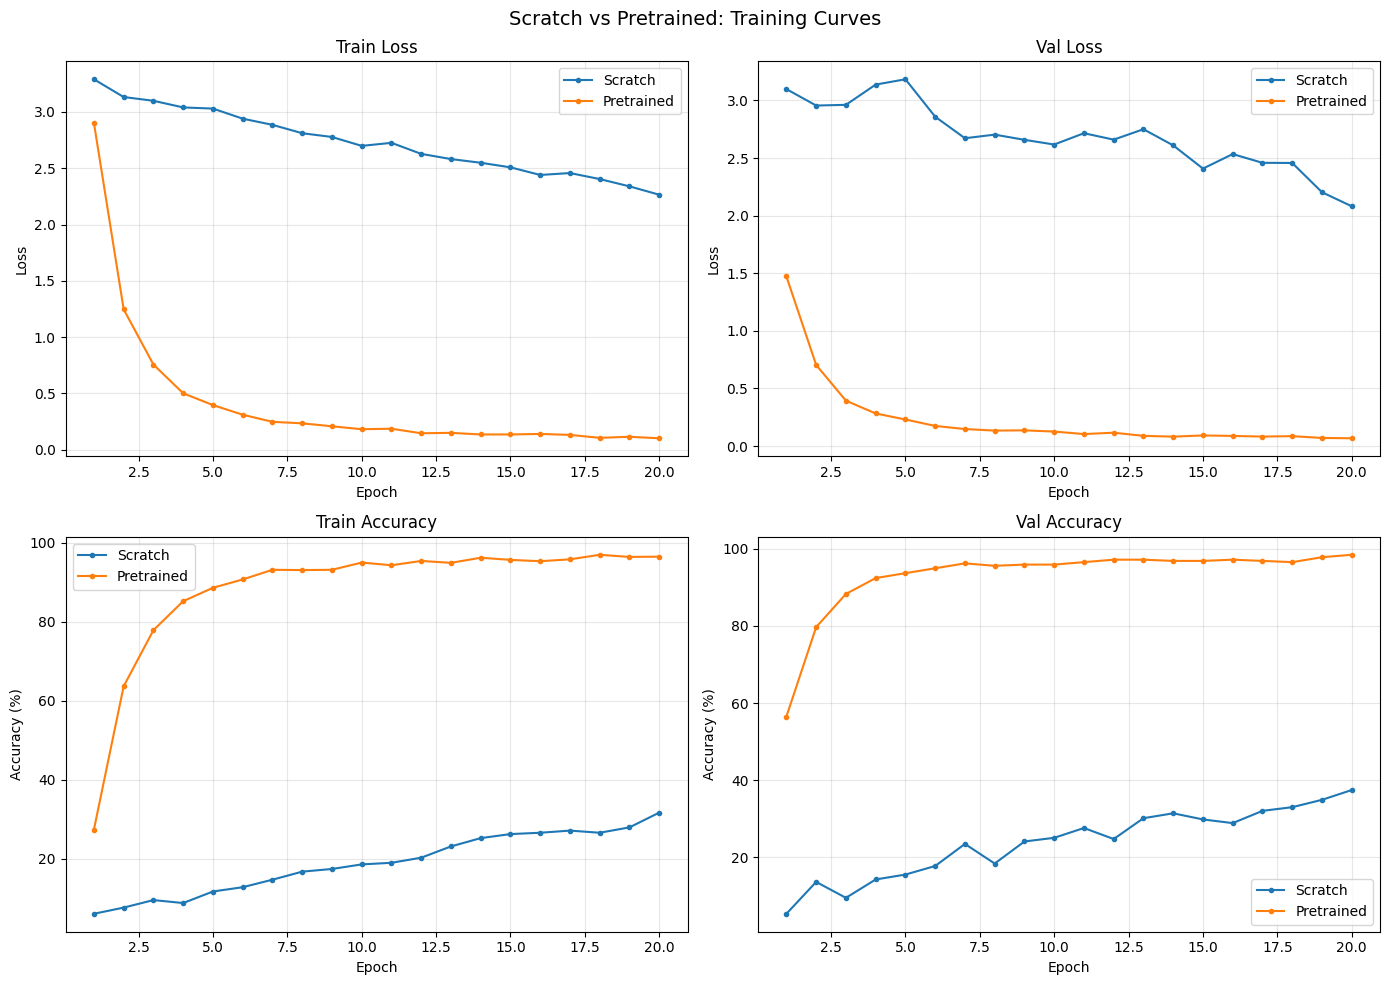

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
ep_s = range(1, len(history_scratch["train_loss"]) + 1)
ep_p = range(1, len(history_pretrained["train_loss"]) + 1)

titles = ["Train Loss", "Val Loss", "Train Accuracy", "Val Accuracy"]
keys = ["train_loss", "val_loss", "train_acc", "val_acc"]
ylabels = ["Loss", "Loss", "Accuracy (%)", "Accuracy (%)"]

for ax, title, key, ylabel in zip(axes.flatten(), titles, keys, ylabels):
    ax.plot(ep_s, history_scratch[key], label="Scratch", marker='o', ms=3)
    ax.plot(ep_p, history_pretrained[key], label="Pretrained", marker='o', ms=3)
    ax.set(xlabel="Epoch", ylabel=ylabel, title=title)
    ax.legend()
    ax.grid(alpha=0.3)

fig.suptitle("Scratch vs Pretrained: Training Curves", fontsize=14)
plt.tight_layout()
plt.show()

In the graphs we see that the accuracy of the pretrained model drastically increases within the first three epochs, while the one of the model from scratch only slightly increases by mere percentages over the whole 20 epochs. 

When comparing train with validation accuracy, the curves of the pretrained model look very similarly. The validation accuracy of the model from scratch has more peaks and valleys than the one of train accuracy. 

## 3. Confusion Matrices

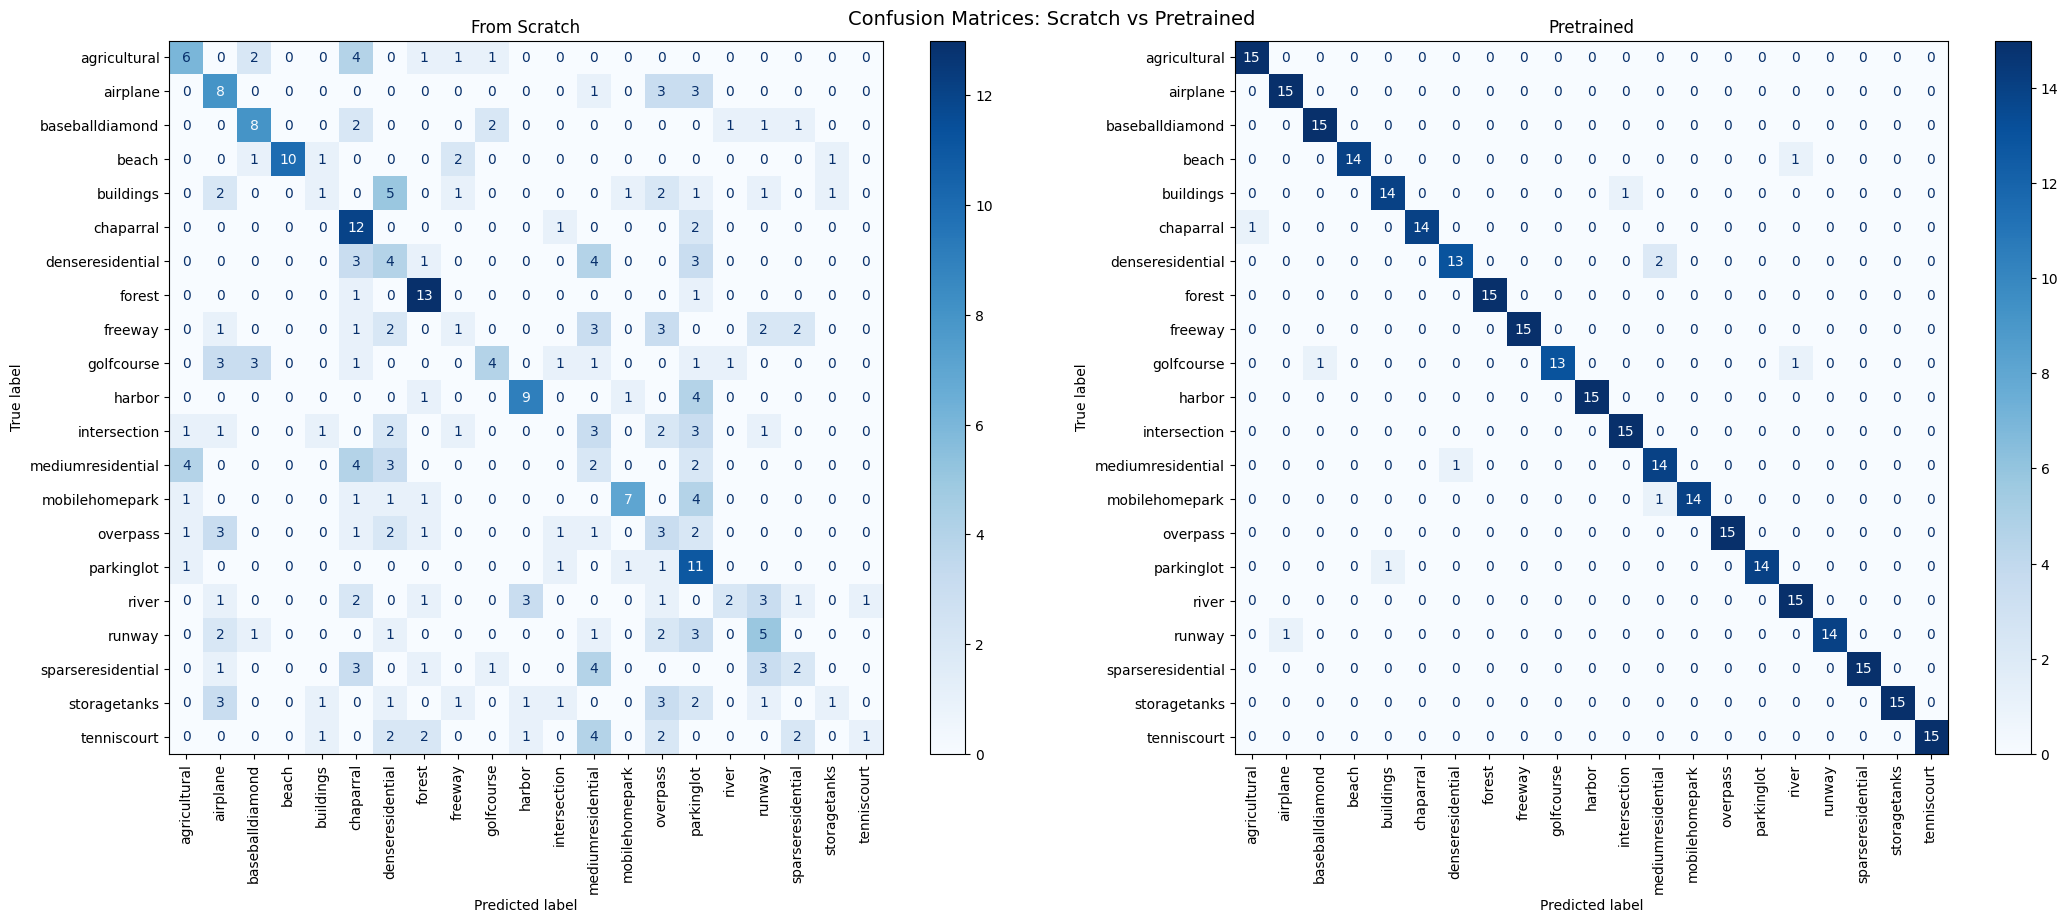

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 9))

cm_scratch = confusion_matrix(labels_scratch, preds_scratch)
ConfusionMatrixDisplay(cm_scratch, display_labels=class_names).plot(
    cmap=plt.cm.Blues, ax=ax1, xticks_rotation=90)
ax1.set_title("From Scratch")

cm_pretrained = confusion_matrix(labels_pretrained, preds_pretrained)
ConfusionMatrixDisplay(cm_pretrained, display_labels=class_names).plot(
    cmap=plt.cm.Blues, ax=ax2, xticks_rotation=90)
ax2.set_title("Pretrained")

fig.suptitle("Confusion Matrices: Scratch vs Pretrained", fontsize=14)
plt.tight_layout()
plt.show()

The confusion matrices also show that the pretrained model predicted more samples correctly than the model from scratch. 

The worst categories of the pretrained model with only 13 out of 15 samples correctly classified, were "dense residential" and "golf course". Dense residential was confused two times with "medium residential". 

While 13 out of 15 correct classification was the lowest score for the pretrained model, it is the highest for the model from scratch. It achieved this for categorization of "forest". It did not classify any sample from the "intersection"-class correctly, it confused it mostly with "medium resedential" and "parking lot". Over all categories, it mistook samples from "buildings" the most often, in fact five times, for "dense residential".

In [7]:
print("=== Classification Report: From Scratch ===")
print(classification_report(labels_scratch, preds_scratch, target_names=class_names))

print("\n=== Classification Report: Pretrained ===")
print(classification_report(labels_pretrained, preds_pretrained, target_names=class_names))

=== Classification Report: From Scratch ===
                   precision    recall  f1-score   support

     agricultural       0.43      0.40      0.41        15
         airplane       0.32      0.53      0.40        15
  baseballdiamond       0.53      0.53      0.53        15
            beach       1.00      0.67      0.80        15
        buildings       0.20      0.07      0.10        15
        chaparral       0.34      0.80      0.48        15
 denseresidential       0.17      0.27      0.21        15
           forest       0.59      0.87      0.70        15
          freeway       0.14      0.07      0.09        15
       golfcourse       0.50      0.27      0.35        15
           harbor       0.64      0.60      0.62        15
     intersection       0.00      0.00      0.00        15
mediumresidential       0.08      0.13      0.10        15
   mobilehomepark       0.70      0.47      0.56        15
         overpass       0.14      0.20      0.16        15
       park

## 4. Discussion

**a) Accuracy & Convergence:**
- Which model achieves higher test accuracy? the pretrained model
- Which model converges faster (reaches good validation accuracy sooner)? also the pretrained model

**b) Hardest Classes:**
- Which classes have the lowest F1-score for each model? 
    * scratch: intersection (0.00), freeway (0.09), buildings (0.10), medium residential (0.10), storage tanks (0.11)
    * pretrained: buildings (0.93), golf course (0.93), river (0.94)
- Which classes get confused with each other? (look at the confusion matrix)
    * buildings and dense residential
    * dense residential and medium residential
- Why? (think about visual similarity, e.g., `dense_residential` vs `medium_residential`)
    * They are probably viusally very similar, buildings appear often in dense residential areas, dense and medium residential areas also looks probably similar. 

**c) Pretrained vs Scratch:**
- Why does transfer learning help (or not) for this dataset? <br>It helps a lot because there are many different classes (21) and only 2,100 samples in total. After dividing these into train, validation, and test datasets, only 1,470 samples are left for training. Additionally, training for only 20 epochs definitely does not profit the accuracy of the model from scratch. Pretrained models that already learned to differentiate and detect common objects work way better since we only need to "finetune" it to our dataset. 
- Are there classes where one model does better than the other? Not really, the pretrained model does better for every class. 